In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import optuna # Import Optuna for hyperparameter tuning
import yfinance as yf # Import yfinance to download stock data
from datetime import timedelta

In [ ]:
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
except ImportError:
    print("Error: TensorFlow tidak terinstal.")
    print("Silakan instal dengan: pip install tensorflow")
    exit()

In [ ]:
import yfinance as yf

In [ ]:
print("Mengunduh data saham BABA dari Yahoo Finance...")
ticker_symbol = 'BABA'
start_date = '2015-01-01'
end_date = '2024-12-31' # Or use pd.Timestamp.now().strftime('%Y-%m-%d') for today's date

# Unduh data
df = yf.download(ticker_symbol, start=start_date, end=end_date)
df.head()

Mengunduh data saham BABA dari Yahoo Finance...


/tmp/ipython-input-4-2455470508.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker_symbol, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,BABA,BABA,BABA,BABA,BABA
Date,,,,,
2015-01-02,100.051346,101.132985,99.008338,100.669423,12303400
2015-01-05,97.540413,99.491218,96.478093,99.240129,18337000
2015-01-06,99.780937,100.292782,96.680892,97.781842,15720400
2015-01-07,98.631699,101.152298,98.535125,101.007434,11052200
2015-01-08,101.432365,101.731745,99.162862,99.423611,12942100


In [ ]:
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.droplevel(1)

In [ ]:
df.index.name = 'Tanggal' # Set index name to 'Tanggal'
df.sort_index(inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2515 entries, 2015-01-02 to 2024-12-30
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   2515 non-null   float64
 1   High    2515 non-null   float64
 2   Low     2515 non-null   float64
 3   Open    2515 non-null   float64
 4   Volume  2515 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 117.9 KB


Karakteristik Data

In [ ]:
print(df.describe())

Price        Close         High          Low         Open        Volume
count  2515.000000  2515.000000  2515.000000  2515.000000  2.515000e+03
mean    132.155072   133.871127   130.411645   132.252885  1.865308e+07
std      57.411061    58.025260    56.719975    57.492179  1.166581e+07
min      55.424198    56.641038    55.240704    55.337277  3.775300e+06
25%      82.001545    82.997168    81.170503    82.136757  1.182095e+07
50%     108.955536   110.915999   106.531515   109.235601  1.588420e+07
75%     174.664932   176.843662   172.434058   174.645625  2.133240e+07
max     306.276886   308.382206   298.328791   302.761578  1.598343e+08


In [ ]:
statdes = df.describe()
statdes_2digit = statdes.round(2)
print(statdes_2digit)

Price    Close     High      Low     Open        Volume
count  2515.00  2515.00  2515.00  2515.00  2.515000e+03
mean    132.16   133.87   130.41   132.25  1.865308e+07
std      57.41    58.03    56.72    57.49  1.166581e+07
min      55.42    56.64    55.24    55.34  3.775300e+06
25%      82.00    83.00    81.17    82.14  1.182095e+07
50%     108.96   110.92   106.53   109.24  1.588420e+07
75%     174.66   176.84   172.43   174.65  2.133240e+07
max     306.28   308.38   298.33   302.76  1.598343e+08


# Cleaning Data and EDA

In [ ]:
df.isna().sum()

,0
Price,
Close,0
High,0
Low,0
Open,0
Volume,0


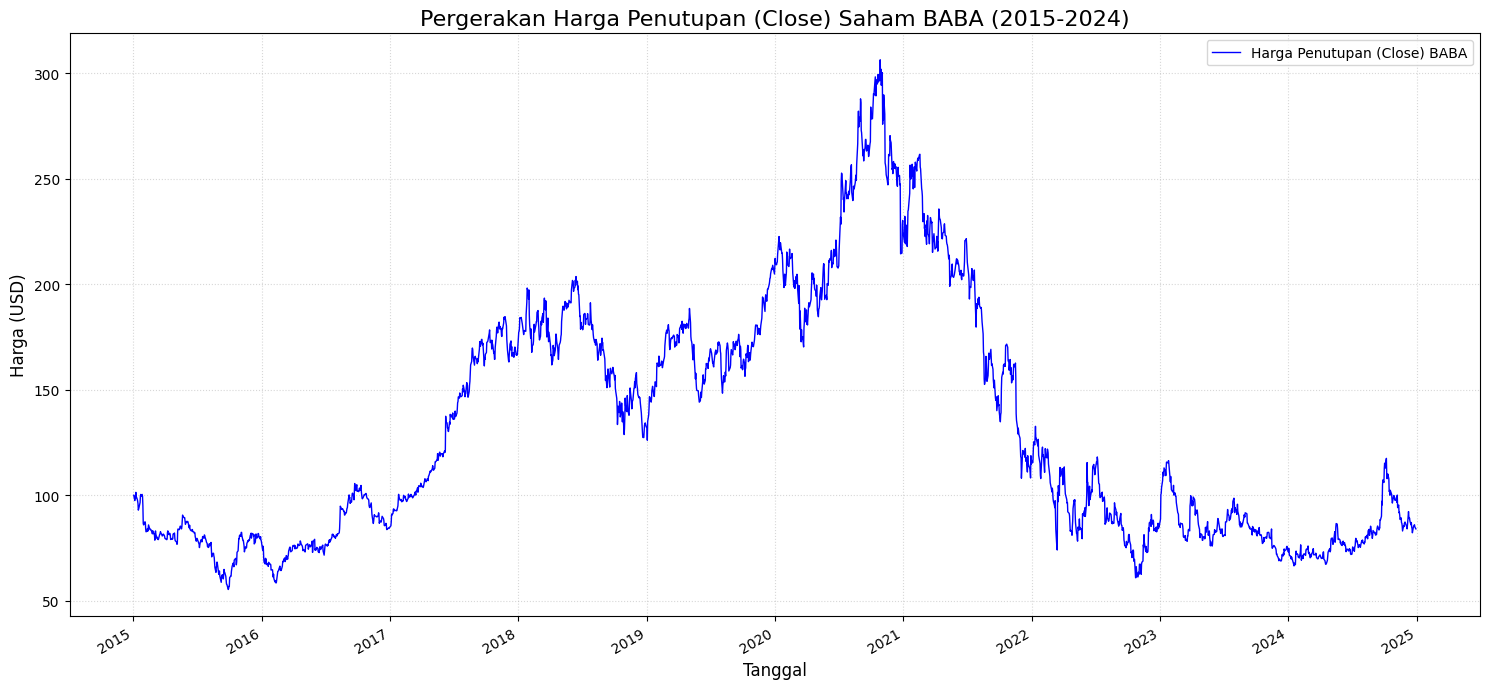

In [ ]:
plt.figure(figsize=(15, 7))
plt.plot(df.index, df['Close'], label='Harga Penutupan (Close) BABA', color='blue', linewidth=1)
plt.title('Pergerakan Harga Penutupan (Close) Saham BABA (2015-2024)', fontsize=16)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Harga (USD)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.5)
plt.legend(fontsize=10)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

# XGBoost

In [ ]:
df['target_close'] = df['Close'].shift(-1) # Target is now based on 'Close'

In [ ]:
df.dropna(subset=['Close', 'target_close'], inplace=True) # Changed subset to 'Close'
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2514 entries, 2015-01-02 to 2024-12-27
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Close         2514 non-null   float64
 1   High          2514 non-null   float64
 2   Low           2514 non-null   float64
 3   Open          2514 non-null   float64
 4   Volume        2514 non-null   int64  
 5   target_close  2514 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 137.5 KB


In [ ]:
X_raw = df[['Close']] # Only use 'Close' column as raw feature
y_raw = df['target_close']

print("\nShape dari Fitur Mentah (X_raw):", X_raw.shape)
print("Shape dari Target Mentah (y_raw):", y_raw.shape)


Shape dari Fitur Mentah (X_raw): (2514, 1)
Shape dari Target Mentah (y_raw): (2514,)


### Split Data

In [ ]:
test_start_date = '2023-01-01'

# Pastikan indeks adalah datetime agar bisa difilter berdasarkan tanggal
if not isinstance(X_raw.index, pd.DatetimeIndex):
    print("Error: Indeks DataFrame bukan tipe DatetimeIndex. Pastikan kolom 'Tanggal' sudah dikonversi dan diset sebagai indeks.")
    # Anda mungkin perlu menambahkan kode untuk mengonversi indeks di sini jika ini terjadi
    # Contoh: X_raw.index = pd.to_datetime(X_raw.index)

X_train_raw = X_raw[X_raw.index < test_start_date]
X_test_raw = X_raw[X_raw.index >= test_start_date]
y_train_raw = y_raw[y_raw.index < test_start_date]
y_test_raw = y_raw[y_raw.index >= test_start_date]


print(f"\nUkuran data training mentah (X_train_raw): {X_train_raw.shape}, (y_train_raw): {y_train_raw.shape}")
print(f"Ukuran data testing mentah (X_test_raw): {X_test_raw.shape}, (y_test_raw): {y_test_raw.shape}")



Ukuran data training mentah (X_train_raw): (2014, 1), (y_train_raw): (2014,)
Ukuran data testing mentah (X_test_raw): (500, 1), (y_test_raw): (500,)


### Feature Engineering

In [ ]:
def apply_feature_engineering(df_subset, y_subset):
    # Buat salinan untuk menghindari SettingWithCopyWarning
    df_engineered = df_subset.copy()
    y_engineered = y_subset.copy()

    # 1. Fitur Berbasis Waktu (tidak bergantung pada kolom harga spesifik selain indeks)
    df_engineered['tahun'] = df_engineered.index.year
    df_engineered['bulan'] = df_engineered.index.month
    df_engineered['hari_of_week'] = df_engineered.index.dayofweek
    df_engineered['hari_of_month'] = df_engineered.index.day
    df_engineered['kuartal'] = df_engineered.index.quarter
    df_engineered['minggu_of_year'] = df_engineered.index.isocalendar().week.astype(int)

    # 2. Fitur Lagged (Nilai Historis)
    # Hanya menggunakan 'Close'
    lag_periods = [1, 2, 3, 5, 7, 10, 14, 21] # Menambah beberapa periode lag
    lag_features_base = ['Close']

    for period in lag_periods:
        for col in lag_features_base:
            df_engineered[f'{col}_lag{period}'] = df_engineered[col].shift(period)

    # 3. Fitur Rolling (Moving Averages, Standard Deviations)
    # Hanya menggunakan 'Close'
    window_sizes = [5, 10, 20, 50, 100, 200] # Menambah beberapa ukuran window
    for window in window_sizes:
        df_engineered[f'MA_{window}'] = df_engineered['Close'].rolling(window=window).mean()
        df_engineered[f'STD_{window}'] = df_engineered['Close'].rolling(window=window).std()

    # 6. Fitur Momentum (Berdasarkan Moving Averages dari 'Close')
    # Pastikan MA yang dibutuhkan sudah terhitung
    df_engineered['MA_5_vs_20'] = df_engineered['MA_5'] - df_engineered['MA_20']
    df_engineered['MA_10_vs_50'] = df_engineered['MA_10'] - df_engineered['MA_50']
    df_engineered['price_relative_to_MA5'] = df_engineered['Close'] / df_engineered['MA_5']
    df_engineered['price_relative_to_MA20'] = df_engineered['Close'] / df_engineered['MA_20']
    df_engineered['price_relative_to_MA50'] = df_engineered['Close'] / df_engineered['MA_50']


    # Drop NaNs yang muncul dari fitur lagged dan rolling
    # Ini akan menghapus baris-baris awal dalam setiap subset
    rows_with_nan = df_engineered.isnull().any(axis=1)
    df_engineered = df_engineered.loc[~rows_with_nan]
    y_engineered = y_engineered.loc[~rows_with_nan]

    # Hapus kolom asli 'Close' karena sudah menjadi dasar fitur-fitur baru
    cols_to_drop_from_features = ['Close']
    df_engineered = df_engineered.drop(columns=cols_to_drop_from_features, errors='ignore')

    return df_engineered, y_engineered

print("\nMelakukan Feature Engineering pada data training dan testing...")
X_train_fe, y_train_fe = apply_feature_engineering(X_train_raw, y_train_raw)
X_test_fe, y_test_fe = apply_feature_engineering(X_test_raw, y_test_raw)

print(f"\nUkuran data training setelah FE (X_train_fe): {X_train_fe.shape}, (y_train_fe): {y_train_fe.shape}")
print(f"Ukuran data testing setelah FE (X_test_fe): {X_test_fe.shape}, (y_test_fe): {y_test_fe.shape}")



Melakukan Feature Engineering pada data training dan testing...

Ukuran data training setelah FE (X_train_fe): (1815, 31), (y_train_fe): (1815,)
Ukuran data testing setelah FE (X_test_fe): (301, 31), (y_test_fe): (301,)


### Tuning Hyperparameter

In [ ]:
def objective(trial):
    # Membagi X_train_fe dan y_train_fe menjadi training dan validation set
    # untuk hyperparameter tuning (mencegah data leakage dari test set)
    # Gunakan 80% dari X_train_fe untuk training Optuna, 20% untuk validation Optuna
    train_tuning_size = int(len(X_train_fe) * 0.8)
    X_train_optuna = X_train_fe.iloc[:train_tuning_size]
    y_train_optuna = y_train_fe.iloc[:train_tuning_size]
    X_val_optuna = X_train_fe.iloc[train_tuning_size:]
    y_val_optuna = y_train_fe.iloc[train_tuning_size:]

    # Saran hyperparameter untuk XGBoost
    param = {
        'objective': 'reg:squarederror',
        'n_estimators': trial.suggest_int('n_estimators', 100, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma': trial.suggest_float('gamma', 0.0, 0.5), # Regularization parameter
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 0.5), # L1 regularization
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 0.5), # L2 regularization
        'random_state': 42,
        'n_jobs': -1,
    }

    # Inisialisasi dan latih model dengan hyperparameter yang disarankan
    model_optuna = XGBRegressor(**param)
    # Latih model pada data training untuk tuning (X_train_optuna)
    model_optuna.fit(X_train_optuna, y_train_optuna)

    # Buat prediksi pada data VALIDATION untuk tuning (X_val_optuna)
    predictions_optuna = model_optuna.predict(X_val_optuna)

    # Hitung metrik yang akan dioptimalkan (misal: RMSE) pada data VALIDATION
    rmse_optuna = np.sqrt(mean_squared_error(y_val_optuna, predictions_optuna))

    return rmse_optuna

print("\nMemulai Hyperparameter Tuning dengan Optuna...")
# Buat studi Optuna. 'minimize' karena kita ingin mengurangi RMSE.
study = optuna.create_study(direction='minimize')
# Jalankan studi Optuna. n_trials adalah berapa banyak kombinasi hyperparameter yang akan dicoba.
study.optimize(objective, n_trials=50) # Anda bisa menambah n_trials untuk pencarian yang lebih menyeluruh

print("\nHyperparameter Tuning selesai.")
print(f"RMSE terbaik (pada validation set): {study.best_value:.4f}")
print("Hyperparameter terbaik:", study.best_params)

[I 2025-07-06 13:37:45,947] A new study created in memory with name: no-name-6cf1aec8-9686-4d18-903c-25bb53f8fb61



Memulai Hyperparameter Tuning dengan Optuna...


[I 2025-07-06 13:37:47,310] Trial 0 finished with value: 11.358534447647838 and parameters: {'n_estimators': 1596, 'learning_rate': 0.07820739517597163, 'max_depth': 9, 'subsample': 0.8490702950795636, 'colsample_bytree': 0.7342594477172297, 'gamma': 0.12851119264079208, 'reg_alpha': 0.3290999388082892, 'reg_lambda': 0.08934396936260536}. Best is trial 0 with value: 11.358534447647838.
[I 2025-07-06 13:37:50,773] Trial 1 finished with value: 10.980093211374534 and parameters: {'n_estimators': 403, 'learning_rate': 0.026976828975378123, 'max_depth': 10, 'subsample': 0.7187740090709378, 'colsample_bytree': 0.8132125468791903, 'gamma': 0.441480316459947, 'reg_alpha': 0.21305792370524002, 'reg_lambda': 0.12377060294036663}. Best is trial 1 with value: 10.980093211374534.
[I 2025-07-06 13:37:51,512] Trial 2 finished with value: 13.067230406110916 and parameters: {'n_estimators': 887, 'learning_rate': 0.12159577785916265, 'max_depth': 10, 'subsample': 0.8848982697552092, 'colsample_bytree': 


Hyperparameter Tuning selesai.
RMSE terbaik (pada validation set): 7.0392
Hyperparameter terbaik: {'n_estimators': 145, 'learning_rate': 0.057109613134069405, 'max_depth': 3, 'subsample': 0.6155212425237249, 'colsample_bytree': 0.8903898806960737, 'gamma': 0.300141414393313, 'reg_alpha': 0.053498896805158624, 'reg_lambda': 0.47851748348826034}


In [ ]:
best_model = XGBRegressor(objective='reg:squarederror',
                          **study.best_params, # Gunakan hyperparameter terbaik dari Optuna
                          random_state=42,
                          n_jobs=-1)

# Latih model terbaik pada data training yang sudah di-feature engineering
best_model.fit(X_train_fe, y_train_fe)
print("Model terbaik berhasil dilatih.")

predictions_train = best_model.predict(X_train_fe)

# Buat prediksi pada data testing
predictions_test = best_model.predict(X_test_fe)

Model terbaik berhasil dilatih.


In [ ]:
# --- 7. Evaluasi Model Terbaik ---
# Evaluasi pada Data Training
mae_train = mean_absolute_error(y_train_fe, predictions_train)
mse_train = mean_squared_error(y_train_fe, predictions_train)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train_fe, predictions_train)

print(f"\n--- Hasil Evaluasi Model Terbaik (pada Training Set) ---")
print(f"Mean Absolute Error (MAE): {mae_train:.4f}")
print(f"Mean Squared Error (MSE): {mse_train:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_train:.4f}")
print(f"R-squared (R2): {r2_train:.4f}")


# Evaluasi pada Data Testing
mae_test = mean_absolute_error(y_test_fe, predictions_test)
mse_test = mean_squared_error(y_test_fe, predictions_test)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test_fe, predictions_test)

print(f"\n--- Hasil Evaluasi Model Terbaik (pada Test Set Murni) ---")
print(f"Mean Absolute Error (MAE): {mae_test:.4f}")
print(f"Mean Squared Error (MSE): {mse_test:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_test:.4f}")
print(f"R-squared (R2): {r2_test:.4f}")


--- Hasil Evaluasi Model Terbaik (pada Training Set) ---
Mean Absolute Error (MAE): 2.4707
Mean Squared Error (MSE): 11.3085
Root Mean Squared Error (RMSE): 3.3628
R-squared (R2): 0.9965

--- Hasil Evaluasi Model Terbaik (pada Test Set Murni) ---
Mean Absolute Error (MAE): 1.7103
Mean Squared Error (MSE): 5.5045
Root Mean Squared Error (RMSE): 2.3462
R-squared (R2): 0.9475


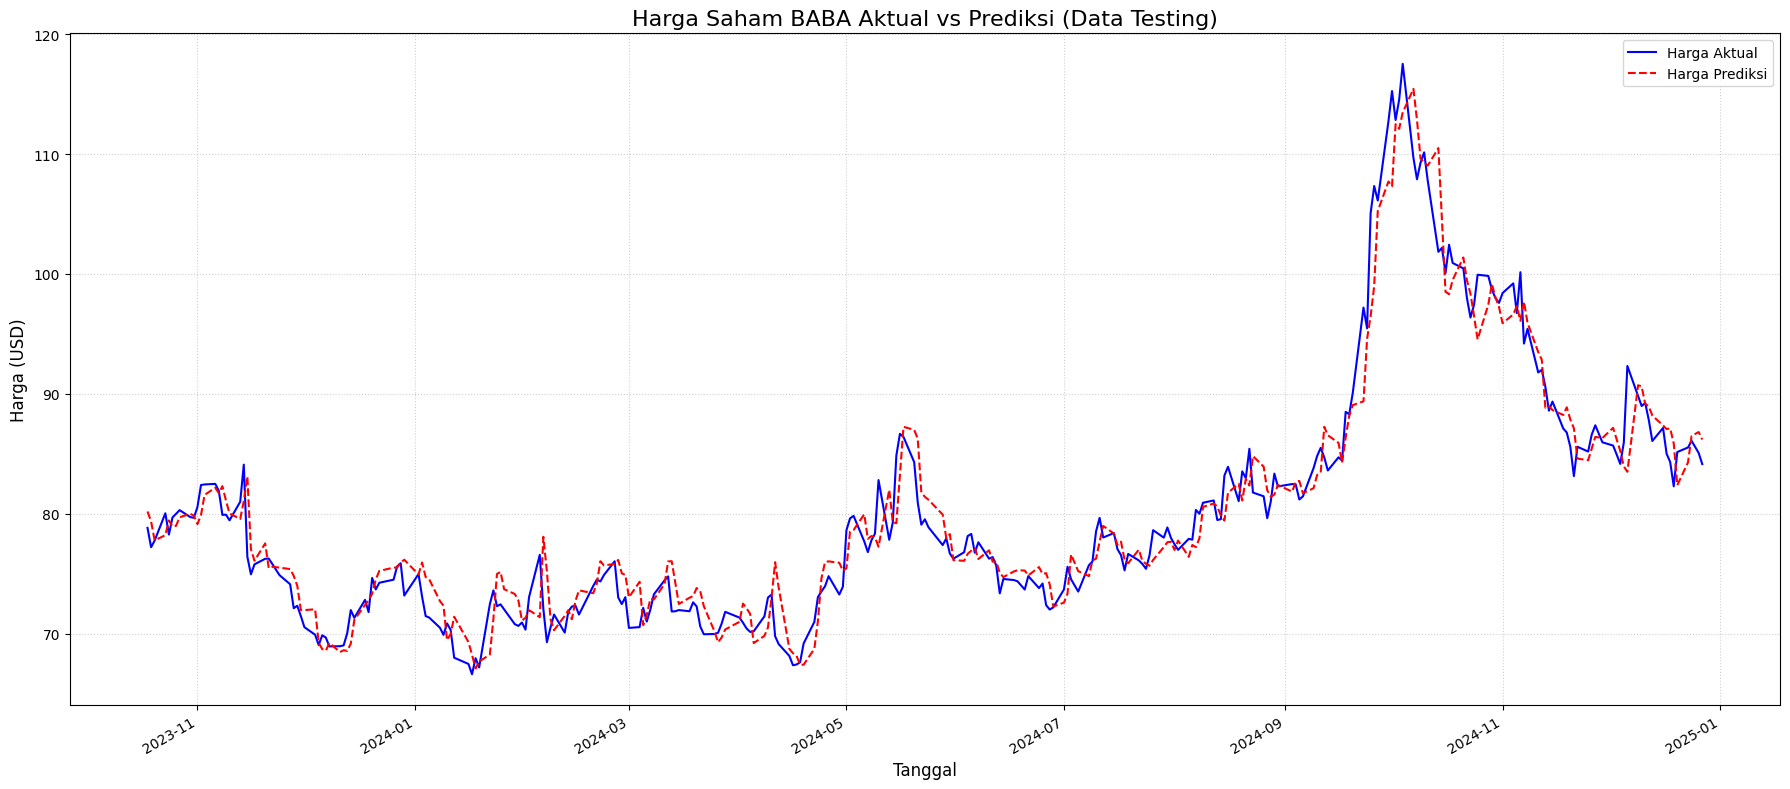

In [ ]:
plt.figure(figsize=(18, 8))
plt.plot(y_test_fe.index, y_test_fe, label='Harga Aktual', color='blue', linewidth=1.5)
plt.plot(y_test_fe.index, predictions, label='Harga Prediksi', color='red', linestyle='--', linewidth=1.5) # Perbaikan: gunakan y_test_fe.index
plt.title('Harga Saham BABA Aktual vs Prediksi (Data Testing)', fontsize=16)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Harga (USD)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=10)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

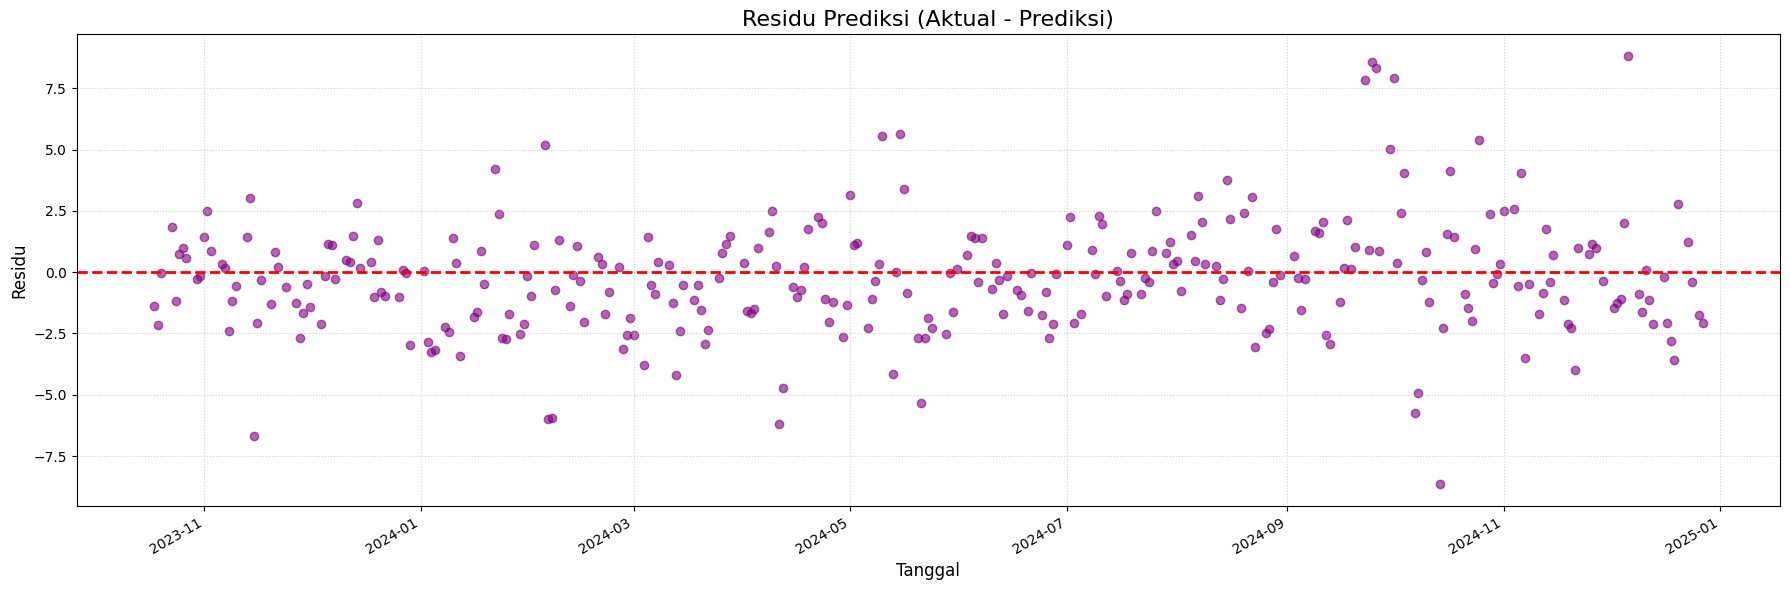

In [ ]:
# Visualisasi Residu (Error)
residuals = y_test_fe - predictions
plt.figure(figsize=(18, 6))
plt.scatter(y_test_fe.index, residuals, alpha=0.6, color='purple')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('Residu Prediksi (Aktual - Prediksi)', fontsize=16)
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Residu', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

### Forecast 60 Hari

In [ ]:
print("\n--- Melakukan Forecasting Beberapa Bulan ke Depan ---")

# Tentukan berapa hari perdagangan ke depan yang akan di-forecast
forecast_trading_days = 60 # Sekitar 3 bulan (20 hari kerja/bulan)

# Ambil data 'Close' terakhir dari DataFrame asli (df) untuk memulai forecasting
# Ini adalah harga 'Close' terakhir yang diketahui dari seluruh dataset
last_known_date = df.index[-1]
last_known_close_price = df['Close'].iloc[-1]

# Siapkan data historis yang cukup untuk perhitungan fitur (lagged, rolling)
# Ambil data 'Close' dari df yang asli, termasuk bagian terakhir dari training dan test
# yang diperlukan untuk menghitung fitur untuk prediksi pertama.
# Gunakan window terbesar (200) + lag terbesar (21) sebagai buffer minimum
max_window_size = max([5, 10, 20, 50, 100, 200]) # Ambil dari window_sizes di apply_feature_engineering
max_lag_size = max([1, 2, 3, 5, 7, 10, 14, 21]) # Ambil dari lag_periods di apply_feature_engineering
required_history_for_fe = max_window_size + max_lag_size + 5 # Tambahkan sedikit buffer ekstra

# Ambil data historis 'Close' yang diperlukan untuk feature engineering
# Ini akan menjadi dasar untuk memprediksi hari pertama forecast
historical_data_for_forecast_fe = df['Close'].iloc[-required_history_for_fe:].copy().to_frame()

# Buat DataFrame untuk menyimpan hasil forecast
forecast_dates = []
forecast_prices = []

# Inisialisasi dengan harga penutupan terakhir yang diketahui
current_date = last_known_date
current_close_price = last_known_close_price

# Loop untuk melakukan forecasting
print(f"Memulai forecast dari tanggal {last_known_date} selama {forecast_trading_days} hari perdagangan...")
for i in range(forecast_trading_days):
    # Dapatkan tanggal hari kerja berikutnya
    next_date = current_date + timedelta(days=1)
    while next_date.weekday() > 4: # 0=Senin, 4=Jumat (lewatkan Sabtu dan Minggu)
        next_date += timedelta(days=1)

    # Tambahkan tanggal baru ke historical_data_for_forecast_fe dengan harga prediksi sebelumnya
    # Ini akan menjadi 'Close' untuk hari yang akan kita gunakan fiturnya
    # Penting: Pastikan kolom 'Close' ada di historical_data_for_forecast_fe
    historical_data_for_forecast_fe.loc[next_date, 'Close'] = current_close_price

    # Pastikan indeks terurut
    historical_data_for_forecast_fe.sort_index(inplace=True)

    # Ambil data yang cukup untuk feature engineering untuk prediksi hari berikutnya
    # Ini harus mencakup semua data historis yang dibutuhkan oleh apply_feature_engineering
    # untuk baris terakhir (yaitu, next_date)
    temp_df_for_fe = historical_data_for_forecast_fe.iloc[-required_history_for_fe:].copy()

    # Apply feature engineering pada data sementara ini
    # Kita tidak punya y_subset untuk forecast, jadi kirim Series kosong atau None
    # Pastikan apply_feature_engineering mengembalikan DataFrame dengan kolom yang diharapkan model
    X_forecast_fe, _ = apply_feature_engineering(temp_df_for_fe, pd.Series(dtype='float64'))

    # Ambil fitur untuk tanggal yang akan diprediksi (baris terakhir dari X_forecast_fe)
    # Pastikan X_forecast_fe tidak kosong setelah FE
    if X_forecast_fe.empty:
        print(f"Peringatan: X_forecast_fe kosong pada iterasi {i}. Menghentikan forecast.")
        break

    latest_features = X_forecast_fe.iloc[[-1]] # Ambil baris fitur terakhir

    # Lakukan prediksi
    next_predicted_price = best_model.predict(latest_features)[0]

    # Simpan hasil forecast
    forecast_dates.append(next_date)
    forecast_prices.append(next_predicted_price)

    # Update current_date dan current_close_price untuk iterasi berikutnya
    current_date = next_date
    current_close_price = next_predicted_price

# Buat DataFrame hasil forecast
forecast_df = pd.DataFrame({'Tanggal': forecast_dates, 'Forecast_Close': forecast_prices})
forecast_df.set_index('Tanggal', inplace=True)

print("\nForecast berhasil dibuat.")
print("5 prediksi forecast pertama:")
print(forecast_df.head())
print(f"Tanggal awal forecast: {forecast_df.index.min()}, Tanggal akhir forecast: {forecast_df.index.max()}")


--- Melakukan Forecasting Beberapa Bulan ke Depan ---
Memulai forecast dari tanggal 2024-12-27 00:00:00 selama 60 hari perdagangan...

Forecast berhasil dibuat.
5 prediksi forecast pertama:
            Forecast_Close
Tanggal                   
2024-12-30       86.056610
2024-12-31       86.540092
2025-01-01       86.476929
2025-01-02       86.476929
2025-01-03       87.475800
Tanggal awal forecast: 2024-12-30 00:00:00, Tanggal akhir forecast: 2025-03-21 00:00:00


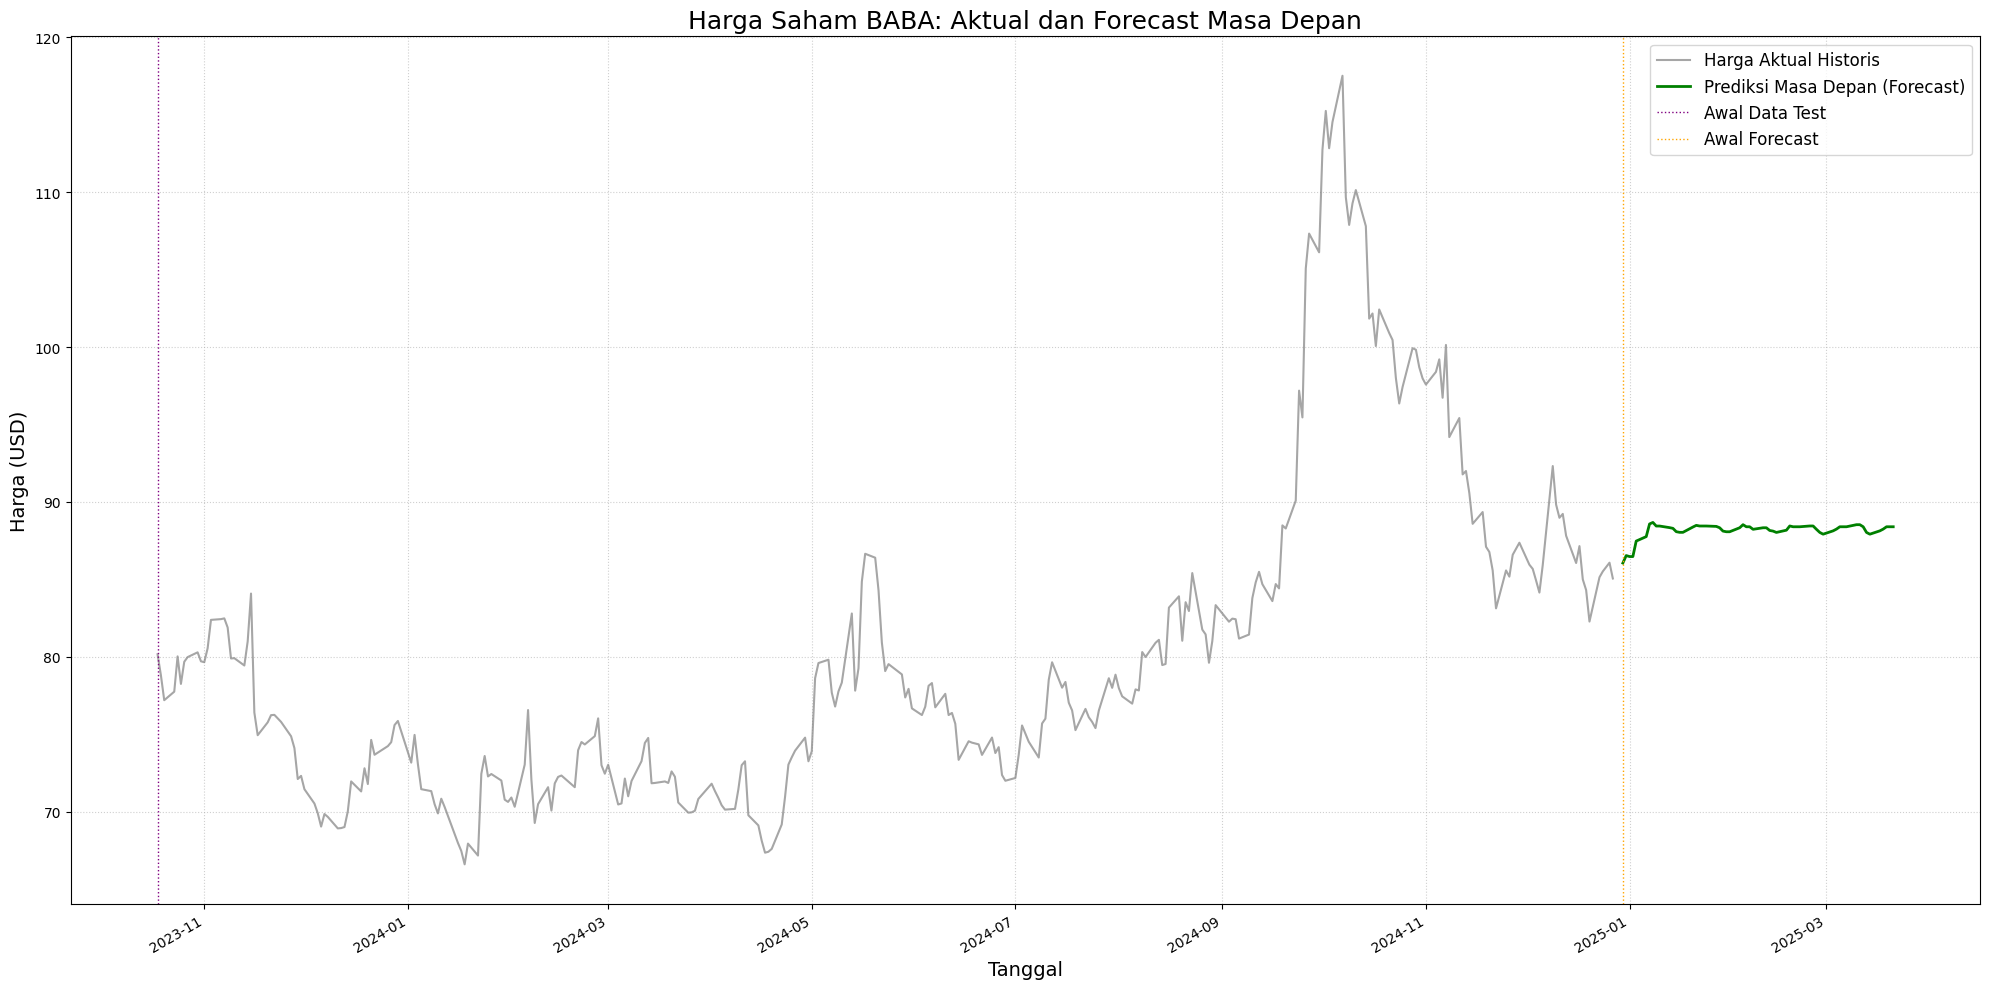

In [ ]:
# --- Visualisasi Hasil Forecast ---
plt.figure(figsize=(20, 10))

# Plot data aktual (training + testing)
# Filter df['Close'] untuk dimulai dari awal data test
# historical_actual_plot_data = df['Close'].loc[y_test_fe.index.min():]
# plt.plot(historical_actual_plot_data.index, historical_actual_plot_data, label='Harga Aktual Historis (Close)', color='gray', alpha=0.7)

# Plot data aktual yang relevan (mulai dari data test)
# Kita hanya ingin plot data aktual dari awal data test hingga akhir data aktual yang tersedia
actual_data_for_plot = df['Close'].loc[y_test_fe.index.min():]
plt.plot(actual_data_for_plot.index, actual_data_for_plot, label='Harga Aktual Historis', color='gray', alpha=0.7, linewidth=1.5)


# Plot prediksi pada data testing (DIHILANGKAN SESUAI PERMINTAAN)
# plt.plot(y_test_fe.index, predictions_test, label='Prediksi Historis (Test Set)', color='red', linestyle='--', linewidth=1.5)

# Plot hasil forecast
plt.plot(forecast_df.index, forecast_df['Forecast_Close'], label='Prediksi Masa Depan (Forecast)', color='green', linestyle='-', linewidth=2)

# Tambahkan garis vertikal untuk menandai awal data test dan awal forecast
plt.axvline(x=y_test_fe.index.min(), color='purple', linestyle=':', linewidth=1, label='Awal Data Test')
plt.axvline(x=forecast_df.index.min(), color='orange', linestyle=':', linewidth=1, label='Awal Forecast')


plt.title('Harga Saham BABA: Aktual dan Forecast Masa Depan', fontsize=18) # Judul disesuaikan
plt.xlabel('Tanggal', fontsize=14)
plt.ylabel('Harga (USD)', fontsize=14)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=12)
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()